In [ ]:
# Clone Project
!git clone https://github.com/dpduy123/AP_ProtoSAM_Amodal.git

Cloning into 'AP_ProtoSAM_Amodal'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 85 (delta 48), reused 63 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (85/85), 49.50 KiB | 1.77 MiB/s, done.
Resolving deltas: 100% (48/48), done.


In [ ]:
%cd /content/AP_ProtoSAM_Amodal

# Verify versions khớp nhau
import torch, torchvision
print(f"torch: {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

# Test nms hoạt động
from torchvision.ops import nms
print("✅ torchvision.nms works")


/content/AP_ProtoSAM_Amodal
torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
CUDA: True
✅ torchvision.nms works


In [ ]:
%run colab_setup.py

✅ GPU: NVIDIA A100-SXM4-40GB (42.4 GB)
▸ pip install -q -r requirements.txt
▸ pip install -q git+https://github.com/facebookresearch/sam2.git
▸ wget -q https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt
✅ Downloaded sam2.1_hiera_large.pt

[Pix2Gestalt] Fetching codebase and 15GB weights...
▸ git clone https://github.com/cvlab-columbia/pix2gestalt.git
▸ cd pix2gestalt && git submodule update --init --recursive
✅ Pix2Gestalt codebase cloned.
▸ wget -q --show-progress -c https://gestalt.cs.columbia.edu/assets/epoch=000005.ckpt -O ckpt/epoch=000005.ckpt
✅ Pix2Gestalt 15.5GB weights downloaded.

✅ All dependencies installed and models loaded!
🚀 A100 mode (42GB) — Full quality, 768px inpainting
Settings: {'device': 'cuda', 'inpaint_size': 768, 'max_iter': 4, 'inference_steps': 40, 'points_per_side': 48, 'guidance_scale': 8.0}


In [ ]:
import numpy as np
from PIL import Image
from google.colab import files

# Upload ảnh
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
img = np.array(Image.open(image_path).convert("RGB"))
print(f"Image: {image_path} | Shape: {img.shape}")

Saving 3cc9c8c4-fb50-44a0-9f85-e36b0fa1d917.jpeg to 3cc9c8c4-fb50-44a0-9f85-e36b0fa1d917.jpeg
Image: 3cc9c8c4-fb50-44a0-9f85-e36b0fa1d917.jpeg | Shape: (256, 256, 3)


In [ ]:
import numpy as np
from PIL import Image
from google.colab import files

image_path = "/content/AP_ProtoSAM_Amodal/polar.png"
img = np.array(Image.open(image_path).convert("RGB"))
print(f"Image: {image_path} | Shape: {img.shape}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/AP_ProtoSAM_Amodal/polar.png'

In [ ]:
# ── Bước 1: SAM Segmentation ──
from segmenter import SAMSegmenter

segmenter = SAMSegmenter()
masks = segmenter.segment_everything(img, points_per_side=32)
print(f"✅ Found {len(masks)} masks")

# Giải phóng SAM để dành VRAM cho SD2
del segmenter
torch.cuda.empty_cache()

[SAMSegmenter] SAM3 unavailable, loading SAM2 on cuda...
[SAMSegmenter] SAM2 loaded.
✅ Found 10 masks


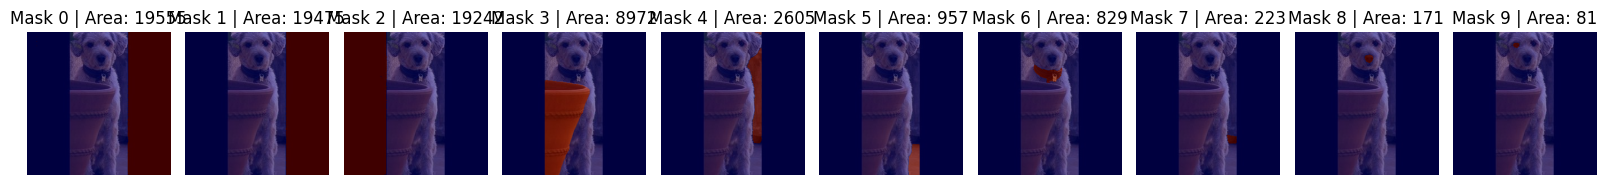

In [ ]:
# ── Xem masks ──
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(masks), figsize=(16, 4))
if len(masks) == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.imshow(img)
    ax.imshow(masks[i]["segmentation"], alpha=0.5, cmap="jet")
    ax.set_title(f"Mask {i} | Area: {masks[i]['area']}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import userdata
import os
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

In [ ]:
# ── Bước 2: Amodal Completion ──
from amodal_completer import AmodalCompleter

# ⚠️ Chọn mask_id muốn complete (xem hình ở trên)
MASK_ID = 3  # <-- thay số này

target_mask = masks[MASK_ID]["segmentation"].astype(bool)

completer = AmodalCompleter()
outputs = completer.complete(
    image=img,
    visible_mask=target_mask,
    all_masks=masks,
    max_iter=3,
)
print("✅ Amodal completion done!")

[AmodalShapePredictor] Loading Pix2Gestalt Checkpoint from ckpt/epoch=000005.ckpt...
LatentDiffusion: Running in eps-prediction mode
DiffusionWrapper has 859.54 M params.
Keeping EMAs of 688.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels
[AmodalShapePredictor] Pix2Gestalt loaded successfully.
[AmodalCompleter] Loading Stable Diffusion inpainting model...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--sd2-community--stable-diffusion-2-inpainting/snapshots/5f74973cbb64c8568780732c17f43eb269d63a0d/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[AmodalCompleter] xformers not available, using attention slicing
[AmodalCompleter] Loading CLIP model...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[AmodalCompleter] Models loaded.
[AmodalCompleter] Step 1: Predicting amodal shape...
[AmodalShapePredictor] Synthesizing amodal object with Pix2Gestalt LDM...
Data shape for DDIM sampling is (1, 4, 32, 32), eta 1.0
Running DDIM Sampling with 199 timesteps


DDIM Sampler: 100%|██████████| 199/199 [00:10<00:00, 19.90it/s]


[AmodalCompleter] Step 4: Synthesizing appearance...
✅ Amodal completion done!


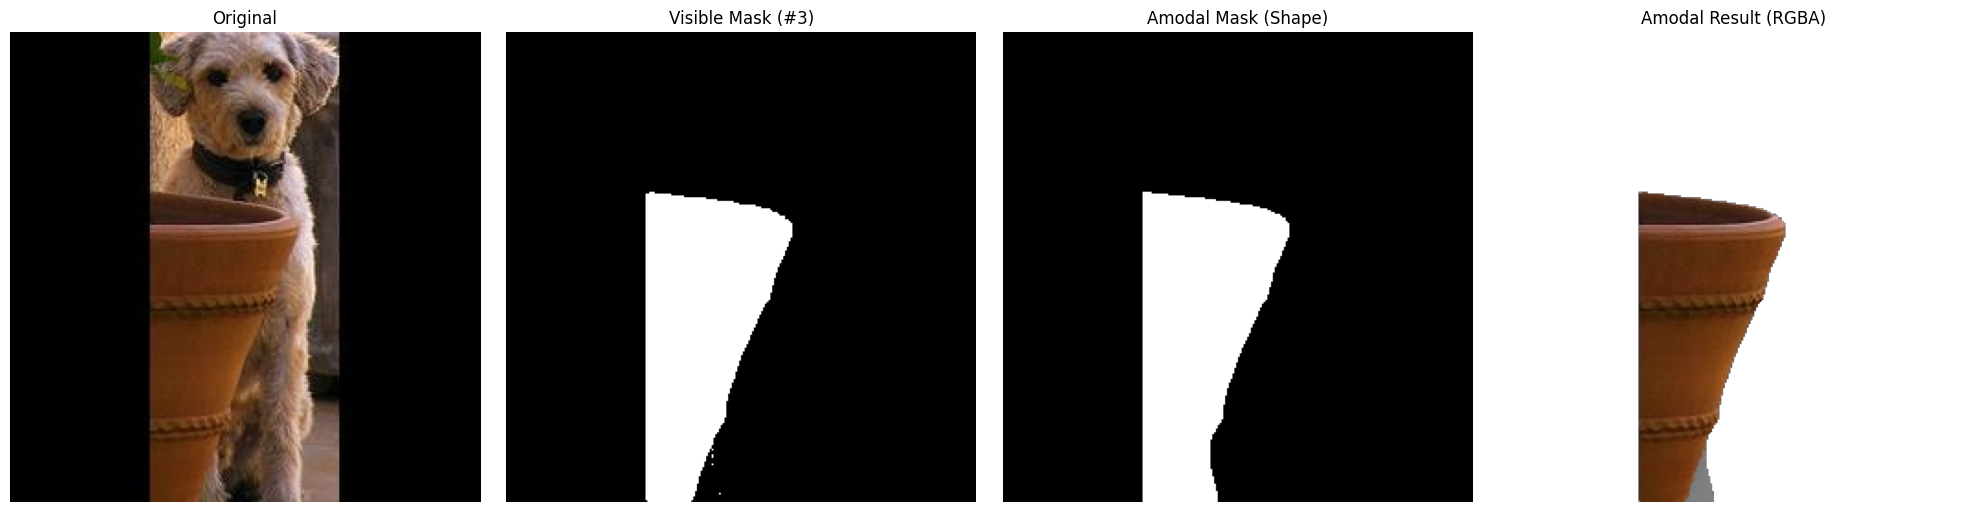

✅ Saved: amodal_result_mask3.png


/tmp/ipykernel_1480/1953993820.py:23: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  result_pil = Image.fromarray(rgba_result, mode="RGBA")


In [ ]:
# ── Xem kết quả ──
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(outputs["input_image"])
axes[0].set_title("Original")

axes[1].imshow(outputs["visible_mask"], cmap="gray")
axes[1].set_title(f"Visible Mask (#{MASK_ID})")

axes[2].imshow(outputs["amodal_mask"], cmap="gray")
axes[2].set_title("Amodal Mask (Shape)")

rgba_result = outputs["inpainted_rgba"]
axes[3].imshow(rgba_result)
axes[3].set_title("Amodal Result (RGBA)")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Lưu kết quả
result_pil = Image.fromarray(rgba_result, mode="RGBA")
output_name = f"amodal_result_mask{MASK_ID}.png"
#result_pil.save(output_name)
print(f"✅ Saved: {output_name}")

# Download về máy
#files.download(output_name)

In [ ]:
import numpy as np
from PIL import Image
from google.colab import files

# Upload ảnh
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
img = np.array(Image.open(image_path).convert("RGB"))
print(f"Image: {image_path} | Shape: {img.shape}")

Saving 28da7e26-9ce5-4f7c-b98b-a55772addc8d.jpeg to 28da7e26-9ce5-4f7c-b98b-a55772addc8d.jpeg
Image: 28da7e26-9ce5-4f7c-b98b-a55772addc8d.jpeg | Shape: (256, 256, 3)


[SAMSegmenter] SAM3 unavailable, loading SAM2 on cuda...
[SAMSegmenter] SAM2 loaded.
✅ Found 3 masks


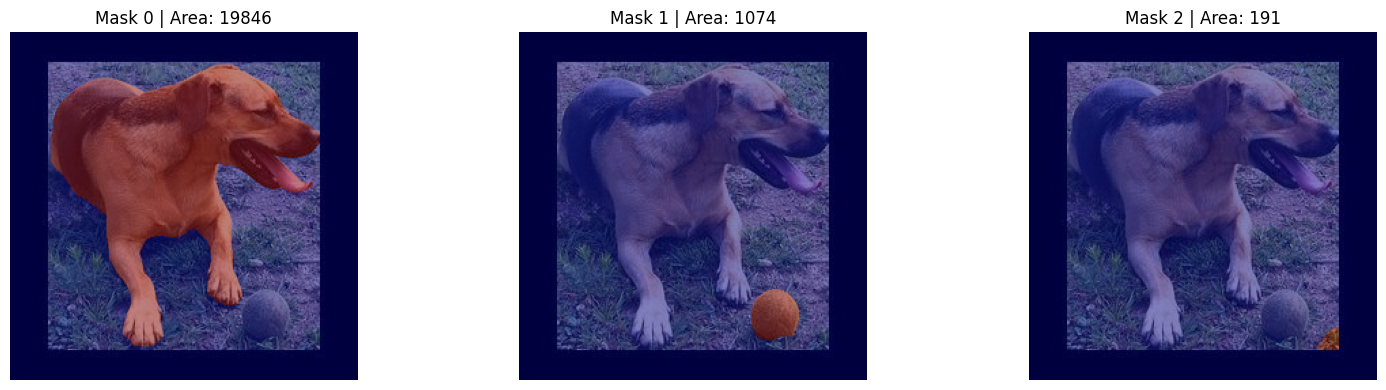

In [ ]:
# ── Bước 1: SAM Segmentation ──
from segmenter import SAMSegmenter

segmenter = SAMSegmenter()
masks = segmenter.segment_everything(img, points_per_side=32)
print(f"✅ Found {len(masks)} masks")

# Giải phóng SAM để dành VRAM cho SD2
del segmenter
torch.cuda.empty_cache()
# ── Xem masks ──
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(masks), figsize=(16, 4))
if len(masks) == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.imshow(img)
    ax.imshow(masks[i]["segmentation"], alpha=0.5, cmap="jet")
    ax.set_title(f"Mask {i} | Area: {masks[i]['area']}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# ── Bước 2: Amodal Completion ──
from amodal_completer import AmodalCompleter

# ⚠️ Chọn mask_id muốn complete (xem hình ở trên)
MASK_ID = 1  # <-- thay số này

target_mask = masks[MASK_ID]["segmentation"].astype(bool)

completer = AmodalCompleter()
outputs = completer.complete(
    image=img,
    visible_mask=target_mask,
    all_masks=masks,
    max_iter=3,
)
print("✅ Amodal completion done!")

[AmodalShapePredictor] Loading Pix2Gestalt Checkpoint from ckpt/epoch=000005.ckpt...
LatentDiffusion: Running in eps-prediction mode
DiffusionWrapper has 859.54 M params.
Keeping EMAs of 688.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels
[AmodalShapePredictor] Pix2Gestalt loaded successfully.
[AmodalCompleter] Loading Stable Diffusion inpainting model...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--sd2-community--stable-diffusion-2-inpainting/snapshots/5f74973cbb64c8568780732c17f43eb269d63a0d/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[AmodalCompleter] xformers not available, using attention slicing
[AmodalCompleter] Loading CLIP model...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[AmodalCompleter] Models loaded.
[AmodalCompleter] Step 1: Predicting amodal shape...
[AmodalShapePredictor] Synthesizing amodal object with Pix2Gestalt LDM...
Data shape for DDIM sampling is (1, 4, 32, 32), eta 1.0
Running DDIM Sampling with 199 timesteps


DDIM Sampler: 100%|██████████| 199/199 [00:09<00:00, 20.75it/s]


[AmodalCompleter] Step 4: Synthesizing appearance...
✅ Amodal completion done!


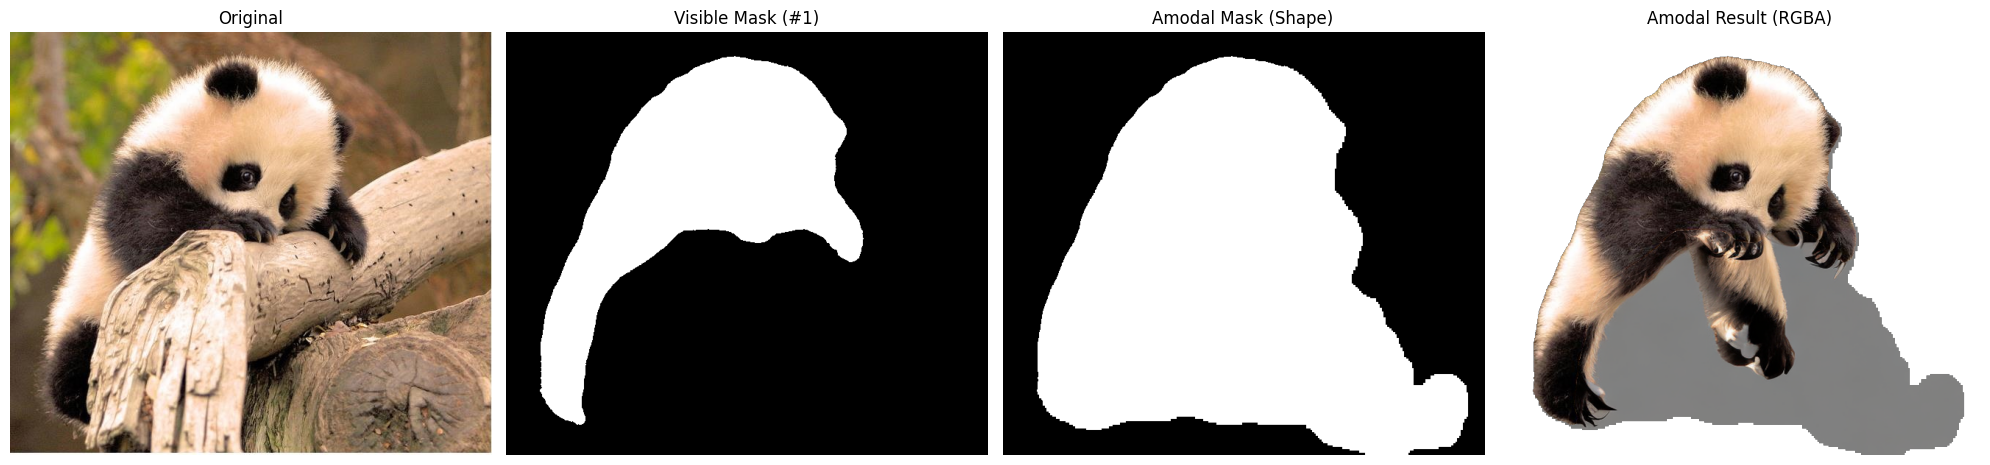

✅ Saved: amodal_result_mask1.png


/tmp/ipykernel_1019/1953993820.py:23: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  result_pil = Image.fromarray(rgba_result, mode="RGBA")


In [ ]:
# ── Xem kết quả ──
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(outputs["input_image"])
axes[0].set_title("Original")

axes[1].imshow(outputs["visible_mask"], cmap="gray")
axes[1].set_title(f"Visible Mask (#{MASK_ID})")

axes[2].imshow(outputs["amodal_mask"], cmap="gray")
axes[2].set_title("Amodal Mask (Shape)")

rgba_result = outputs["inpainted_rgba"]
axes[3].imshow(rgba_result)
axes[3].set_title("Amodal Result (RGBA)")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Lưu kết quả
result_pil = Image.fromarray(rgba_result, mode="RGBA")
output_name = f"amodal_result_mask{MASK_ID}.png"
#result_pil.save(output_name)
print(f"✅ Saved: {output_name}")

# Download về máy
#files.download(output_name)